# 04 Model training (dual head XLM-R)

CSE 4889 Machine Learning: Explainable Multi-Label Hate Speech Detection in Transliterated Bangla

We fine-tune XLM-R on the cleaned BanTH data. The model has two outputs: one says hate or not hate, the other gives a yes/no for each of the 8 hate categories. We save the model to Drive after every epoch, test it on the official test split, and compare it with the BanTH paper.

Before running: Runtime > Change runtime type > T4 GPU. Training takes roughly 20 to 40 minutes.

## Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Check the GPU

Training on CPU would take many hours, so we stop here if no GPU is connected.

In [2]:
import torch
assert torch.cuda.is_available(), 'No GPU. Go to Runtime > Change runtime type > T4 GPU, then run again.'
device = torch.device('cuda')
GPU_NAME = torch.cuda.get_device_name(0)
print('GPU:', GPU_NAME)

GPU: Tesla T4


## Imports, paths and seed

We fix the seed to 42 for Python, NumPy and PyTorch so the training can be repeated. The model code is in src/model.py, so we add the src folder to the Python path.

In [3]:
import os
import re
import sys
import json
import time
import random
import platform
from datetime import datetime
from importlib.metadata import version

import numpy as np
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LambdaLR
from transformers import AutoTokenizer
from sklearn.metrics import (f1_score, accuracy_score, balanced_accuracy_score, hamming_loss,
                             precision_recall_fscore_support, precision_score, recall_score,
                             confusion_matrix)

BASE = '/content/drive/MyDrive/ML_Project'
SEED = 42
NOTEBOOK_NAME = '04_model_training.ipynb'

PROC_DIR = os.path.join(BASE, 'data', 'processed')
FIG_DIR = os.path.join(BASE, 'results', 'figures')
TAB_DIR = os.path.join(BASE, 'results', 'tables')
REP_DIR = os.path.join(BASE, 'results', 'evaluation_reports')
CKPT_DIR = os.path.join(BASE, 'results', 'model_checkpoints')
ASSETS_PATH = os.path.join(BASE, 'results', 'ASSETS.md')
sys.path.append(os.path.join(BASE, 'src'))
from model import DualHeadClassifier, CATEGORIES

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

HATE_COL = 'Label'
TARGET_COLS = CATEGORIES
print('Ready')

Ready


## Helper functions

The same helpers as in the other notebooks: save tables as CSV and LaTeX, add files to ASSETS.md, and one plot style for all figures.

In [4]:
def save_table(df, name, tex_df=None, float_format='%.2f'):
    df.to_csv(os.path.join(TAB_DIR, f'{name}.csv'), index=False)
    (df if tex_df is None else tex_df).to_latex(os.path.join(TAB_DIR, f'{name}.tex'), index=False,
                                                escape=True, float_format=float_format, na_rep='--')
    print('Saved:', name, '(.csv and .tex)')

def register_asset(asset_id, file_name, what, notebook, section, caption):
    row = f'| {asset_id} | {file_name} | {what} | {notebook} | {section} | {caption} |'
    with open(ASSETS_PATH, encoding='utf-8') as f:
        lines = f.read().splitlines()
    lines = [l for l in lines if not l.startswith(f'| {asset_id} |')]
    lines.append(row)
    with open(ASSETS_PATH, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines) + '\n')
    print('Registered', asset_id, '->', file_name)

SPACE_RE = re.compile(r'\s+')
def ascii_short(s, n=60):
    s = SPACE_RE.sub(' ', str(s).encode('ascii', 'ignore').decode()).strip()
    return s if len(s) <= n else s[:n - 3].rstrip() + '...'

BLUE, ORANGE, INK, MUTED = '#2a78d6', '#eb6834', '#0b0b0b', '#52514e'
plt.rcParams.update({
    'font.size': 8, 'axes.labelsize': 8, 'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'legend.fontsize': 7, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': MUTED, 'axes.labelcolor': INK, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': '#e5e4e0', 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'savefig.dpi': 300, 'savefig.bbox': 'tight', 'savefig.facecolor': 'white',
})

## Load the cleaned data

These are the files saved by the data notebook. We train on the clean_text column. keep_default_na=False stops pandas from turning a comment like "NA" into an empty value.

In [5]:
def load_split(name):
    return pd.read_csv(os.path.join(PROC_DIR, f'{name}.csv'), keep_default_na=False)

train_df, val_df, test_df = load_split('train'), load_split('validation'), load_split('test')
assert (len(train_df), len(val_df), len(test_df)) == (29879, 3736, 3735)
print(len(train_df), len(val_df), len(test_df))

29879 3736 3735


## Training settings

We mostly follow the BanTH paper (learning rate 2e-5, batch size 32, up to 5 epochs, early stopping on validation loss) so the comparison is fair. We use AdamW, the usual version of Adam for transformers, with a short warm-up. fp16 (mixed precision) makes training on the T4 about twice as fast.

We picked xlm-roberta-base because XLM-R was the best normally fine-tuned model in the BanTH paper, and the base size fits on a T4.

In [6]:
CONFIG = {
    'model_name': 'xlm-roberta-base',
    'batch_size': 32,
    'eval_batch_size': 64,
    'learning_rate': 2e-5,
    'weight_decay': 0.01,
    'warmup_ratio': 0.1,
    'max_epochs': 5,
    'patience': 2,
    'dropout': 0.1,
    'grad_clip': 1.0,
    'fp16': True,
    'seed': SEED,
}
CONFIG

{'model_name': 'xlm-roberta-base',
 'batch_size': 32,
 'eval_batch_size': 64,
 'learning_rate': 2e-05,
 'weight_decay': 0.01,
 'warmup_ratio': 0.1,
 'max_epochs': 5,
 'patience': 2,
 'dropout': 0.1,
 'grad_clip': 1.0,
 'fp16': True,
 'seed': 42}

## Tokenizer and max length

The tokenizer splits each comment into sub-word pieces. Transliterated words are often split into several pieces, so we measure the real token lengths on the training set. We then pick the smallest max length (64, 128, 256 or 512) that fits at least 99% of comments. The paper used 512, but shorter is much faster and cuts almost nothing.

In [7]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
token_lens = np.array([len(ids) for ids in tokenizer(train_df['clean_text'].tolist())['input_ids']])

MAX_LEN = next(L for L in (64, 128, 256, 512) if (token_lens <= L).mean() >= 0.99)
CONFIG['max_length'] = MAX_LEN
token_stats = {
    'median': float(np.median(token_lens)),
    'p95': float(np.percentile(token_lens, 95)),
    'p99': float(np.percentile(token_lens, 99)),
    'max': int(token_lens.max()),
    'max_length_chosen': MAX_LEN,
    'share_truncated_pct': float(100 * (token_lens > MAX_LEN).mean()),
}
print(token_stats)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (557 > 512). Running this sequence through the model will result in indexing errors


{'median': 15.0, 'p95': 54.0, 'p99': 108.0, 'max': 557, 'max_length_chosen': 128, 'share_truncated_pct': 0.6091234646407175}


## Datasets and data loaders

Each item is the comment text, the hate label, and the 8 category labels. We tokenize each batch when it is loaded and pad only up to the longest comment in that batch. Most comments are short, so this saves a lot of time. The shuffle uses the fixed seed.

In [8]:
class CommentDataset(Dataset):
    def __init__(self, df):
        self.texts = df['clean_text'].tolist()
        self.y_bin = df[HATE_COL].values.astype('float32')
        self.y_cat = df[TARGET_COLS].values.astype('float32')
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, i):
        return self.texts[i], self.y_bin[i], self.y_cat[i]

def collate(batch):
    texts, y_bin, y_cat = zip(*batch)
    enc = tokenizer(list(texts), truncation=True, max_length=MAX_LEN, padding=True, return_tensors='pt')
    return enc['input_ids'], enc['attention_mask'], torch.tensor(np.array(y_bin)), torch.tensor(np.array(y_cat))

g = torch.Generator()
g.manual_seed(SEED)
train_loader = DataLoader(CommentDataset(train_df), batch_size=CONFIG['batch_size'], shuffle=True,
                          collate_fn=collate, generator=g)
val_loader = DataLoader(CommentDataset(val_df), batch_size=CONFIG['eval_batch_size'], collate_fn=collate)
test_loader = DataLoader(CommentDataset(test_df), batch_size=CONFIG['eval_batch_size'], collate_fn=collate)
print(len(train_loader), 'training batches per epoch')

934 training batches per epoch


## The model

XLM-R reads the comment, and we take its output for the first token as a summary of the whole comment. This goes into two small linear layers:
- binary head: 1 output, hate or not hate,
- category head: 8 outputs, one per category, each with its own sigmoid, because a comment can belong to more than one category.

Both heads share the same encoder, so what the model learns for one task also helps the other.

In [9]:
model = DualHeadClassifier(CONFIG['model_name'], dropout=CONFIG['dropout']).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'{n_params / 1e6:.1f}M parameters')

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


278.1M parameters


## Loss, optimizer and learning rate schedule

Both heads use binary cross-entropy, and the total loss is the sum of the two.

Some categories are very rare (Body Shaming has 92 training examples out of 29,879), so the model could learn to always say no for them. To avoid this, the category loss gives more weight to positive examples of rare categories. The weight is sqrt(negatives / positives): we use the square root so the rare classes don't take over completely.

The learning rate rises linearly during the first 10% of steps and then goes down linearly to 0.

In [10]:
pos = train_df[TARGET_COLS].sum().values
neg = len(train_df) - pos
cat_pos_weight = torch.tensor(np.sqrt(neg / pos), dtype=torch.float32, device=device)
print(dict(zip(TARGET_COLS, np.round(np.sqrt(neg / pos), 2))))

bin_loss_fn = nn.BCEWithLogitsLoss()
cat_loss_fn = nn.BCEWithLogitsLoss(pos_weight=cat_pos_weight)
def compute_loss(b_logit, c_logit, y_bin, y_cat):
    return bin_loss_fn(b_logit, y_bin) + cat_loss_fn(c_logit, y_cat)

no_decay = ('bias', 'LayerNorm.weight')
param_groups = [
    {'params': [p for n, p in model.named_parameters() if not any(k in n for k in no_decay)],
     'weight_decay': CONFIG['weight_decay']},
    {'params': [p for n, p in model.named_parameters() if any(k in n for k in no_decay)],
     'weight_decay': 0.0},
]
optimizer = torch.optim.AdamW(param_groups, lr=CONFIG['learning_rate'])

total_steps = len(train_loader) * CONFIG['max_epochs']
warmup_steps = int(CONFIG['warmup_ratio'] * total_steps)
def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    return max(0.0, (total_steps - step) / max(1, total_steps - warmup_steps))
scheduler = LambdaLR(optimizer, lr_lambda)
scaler = torch.amp.GradScaler('cuda', enabled=CONFIG['fp16'])

{'Political': np.float64(5.44), 'Religious': np.float64(16.45), 'Gender': np.float64(12.85), 'Personal Offense': np.float64(2.05), 'Abusive/Violence': np.float64(3.43), 'Origin': np.float64(12.92), 'Body Shaming': np.float64(17.99), 'Misc': np.float64(11.97)}


## Prediction and scoring functions

predict() runs the model on a data loader and returns the average loss and the probabilities from both heads.

The scores are computed the same way as in the BanTH paper, in percent:
- binary: macro-F1 and macro-accuracy (balanced accuracy, which is what the paper calls Acc.), plus normal accuracy and precision, recall and F1 for the hate class,
- multi-label: macro-F1 over the 8 categories, subset accuracy (every label of a comment right) and Hamming loss (share of wrong labels). We also add micro-F1.

In [11]:
@torch.no_grad()
def predict(loader):
    model.eval()
    probs_bin, probs_cat, total, n = [], [], 0.0, 0
    for ids, mask, y_bin, y_cat in loader:
        ids, mask, y_bin, y_cat = ids.to(device), mask.to(device), y_bin.to(device), y_cat.to(device)
        with torch.autocast('cuda', dtype=torch.float16, enabled=CONFIG['fp16']):
            b, c = model(ids, mask)
        b, c = b.float(), c.float()
        total += compute_loss(b, c, y_bin, y_cat).item() * len(y_bin)
        n += len(y_bin)
        probs_bin.append(torch.sigmoid(b).cpu().numpy())
        probs_cat.append(torch.sigmoid(c).cpu().numpy())
    return total / n, np.concatenate(probs_bin), np.concatenate(probs_cat)

def binary_scores(y, pred):
    return {
        'Macro-F1': 100 * f1_score(y, pred, average='macro'),
        'Macro-Acc.': 100 * balanced_accuracy_score(y, pred),
        'Accuracy': 100 * accuracy_score(y, pred),
        'Hate Precision': 100 * precision_score(y, pred, zero_division=0),
        'Hate Recall': 100 * recall_score(y, pred, zero_division=0),
        'Hate F1': 100 * f1_score(y, pred, zero_division=0),
    }

def multilabel_scores(Y, P):
    return {
        'Macro-F1': 100 * f1_score(Y, P, average='macro', zero_division=0),
        'Micro-F1': 100 * f1_score(Y, P, average='micro', zero_division=0),
        'Subset Acc.': 100 * accuracy_score(Y, P),
        'Hamming Loss': 100 * hamming_loss(Y, P),
    }

## Training loop (saved to Drive every epoch)

After every epoch we:
1. check the model on the validation set (loss, binary macro-F1, category macro-F1),
2. add a row to training_log.csv,
3. save the weights to Drive as last_model.pt, and also as best_model.pt when the validation loss is the lowest so far.

We stop early if the validation loss doesn't improve for 2 epochs, like the paper.

If Colab disconnects, run all cells again: training continues from the last saved epoch. The optimizer state is not saved (it would be about 2 GB), so it restarts fresh, which only changes the result slightly. If training already finished, this cell skips training and the rest of the notebook uses the saved best model.

Each checkpoint is about 1.1 GB, so make sure the Drive has around 3 GB free.

In [12]:
LOG_PATH = os.path.join(REP_DIR, 'training_log.csv')
LAST_PATH = os.path.join(CKPT_DIR, 'last_model.pt')
BEST_PATH = os.path.join(CKPT_DIR, 'best_model.pt')
STATE_PATH = os.path.join(CKPT_DIR, 'training_state.json')

state = {'epoch': 0, 'best_val_loss': float('inf'), 'bad_epochs': 0, 'finished': False}
log_rows = []
if os.path.exists(STATE_PATH):
    with open(STATE_PATH) as f:
        state = json.load(f)
    log_rows = pd.read_csv(LOG_PATH).to_dict('records')
    if not state['finished']:
        model.load_state_dict(torch.load(LAST_PATH, map_location=device))
        for _ in range(state['epoch'] * len(train_loader)):
            scheduler.step()
        print('Resuming after epoch', state['epoch'])
    else:
        print('Training already finished, skipping to evaluation.')

y_val = val_df[HATE_COL].values
Y_val = val_df[TARGET_COLS].values

for epoch in range(state['epoch'] + 1, CONFIG['max_epochs'] + 1):
    if state['finished']:
        break
    model.train()
    start, running, seen = time.time(), 0.0, 0
    for step, (ids, mask, y_bin, y_cat) in enumerate(train_loader):
        ids, mask, y_bin, y_cat = ids.to(device), mask.to(device), y_bin.to(device), y_cat.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast('cuda', dtype=torch.float16, enabled=CONFIG['fp16']):
            b, c = model(ids, mask)
        loss = compute_loss(b.float(), c.float(), y_bin, y_cat)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        running += loss.item() * len(y_bin)
        seen += len(y_bin)
        if step % 200 == 0:
            print(f'epoch {epoch} step {step}/{len(train_loader)} loss {running / seen:.4f}')

    val_loss, vb, vc = predict(val_loader)
    row = {
        'epoch': epoch,
        'train_loss': running / seen,
        'val_loss': val_loss,
        'val_binary_macro_f1': binary_scores(y_val, (vb >= 0.5).astype(int))['Macro-F1'],
        'val_multilabel_macro_f1': multilabel_scores(Y_val, (vc >= 0.5).astype(int))['Macro-F1'],
        'minutes': (time.time() - start) / 60,
    }
    log_rows.append(row)
    pd.DataFrame(log_rows).to_csv(LOG_PATH, index=False)
    torch.save(model.state_dict(), LAST_PATH)

    if val_loss < state['best_val_loss']:
        state['best_val_loss'], state['bad_epochs'] = val_loss, 0
        torch.save(model.state_dict(), BEST_PATH)
        note = 'new best, saved best_model.pt'
    else:
        state['bad_epochs'] += 1
        note = f'no improvement ({state["bad_epochs"]}/{CONFIG["patience"]})'
    state['epoch'] = epoch
    state['finished'] = state['bad_epochs'] >= CONFIG['patience'] or epoch == CONFIG['max_epochs']
    with open(STATE_PATH, 'w') as f:
        json.dump(state, f)
    print(f"epoch {epoch}: train {row['train_loss']:.4f} | val {val_loss:.4f} | "
          f"val bin F1 {row['val_binary_macro_f1']:.2f} | val cat F1 {row['val_multilabel_macro_f1']:.2f} | "
          f"{row['minutes']:.1f} min | {note}")

log_df = pd.DataFrame(log_rows)
log_df

/tmp/ipykernel_941/2026347904.py:39: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


epoch 1 step 0/934 loss 1.5965
epoch 1 step 200/934 loss 1.2835
epoch 1 step 400/934 loss 1.1403
epoch 1 step 600/934 loss 1.0737
epoch 1 step 800/934 loss 1.0269
epoch 1: train 1.0030 | val 0.8499 | val bin F1 70.78 | val cat F1 9.96 | 3.8 min | new best, saved best_model.pt
epoch 2 step 0/934 loss 0.8544
epoch 2 step 200/934 loss 0.8081
epoch 2 step 400/934 loss 0.8035
epoch 2 step 600/934 loss 0.8060
epoch 2 step 800/934 loss 0.8007
epoch 2: train 0.7988 | val 0.8019 | val bin F1 76.52 | val cat F1 14.50 | 3.6 min | new best, saved best_model.pt
epoch 3 step 0/934 loss 0.5703
epoch 3 step 200/934 loss 0.7303
epoch 3 step 400/934 loss 0.7234
epoch 3 step 600/934 loss 0.7194
epoch 3 step 800/934 loss 0.7134
epoch 3: train 0.7068 | val 0.7927 | val bin F1 76.49 | val cat F1 18.05 | 3.7 min | new best, saved best_model.pt
epoch 4 step 0/934 loss 0.4449
epoch 4 step 200/934 loss 0.6551
epoch 4 step 400/934 loss 0.6425
epoch 4 step 600/934 loss 0.6496
epoch 4 step 800/934 loss 0.6430
epoc

,epoch,train_loss,val_loss,val_binary_macro_f1,val_multilabel_macro_f1,minutes
0,1,1.003047,0.849866,70.778347,9.957133,3.750924
1,2,0.798815,0.801853,76.524619,14.502727,3.621858
2,3,0.706841,0.792681,76.486031,18.046213,3.713449
3,4,0.639285,0.774243,76.729674,21.879578,3.643642
4,5,0.589879,0.781624,77.003700,24.256040,3.701211


## Loss curves (F04)

Training and validation loss for each epoch. If the validation loss starts going up while the training loss keeps going down, the model is overfitting, and the best epoch is the one with the lowest validation loss.

Registered M05 -> evaluation_reports/training_log.csv


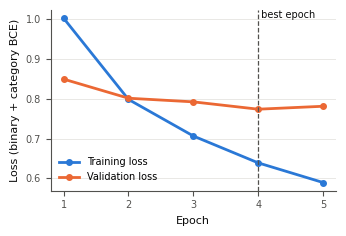

Registered F04 -> figures/fig_04_loss_curves.png


In [13]:
register_asset('M05', 'evaluation_reports/training_log.csv',
               'Per-epoch train loss, validation loss, validation binary and multi-label macro-F1, minutes',
               NOTEBOOK_NAME, 'V. Results (training curves)',
               'Not a figure; source for the training curves and training time.')

best_epoch = int(log_df.loc[log_df['val_loss'].idxmin(), 'epoch'])
fig, ax = plt.subplots(figsize=(3.5, 2.4))
ax.plot(log_df['epoch'], log_df['train_loss'], color=BLUE, linewidth=2, marker='o', markersize=4, label='Training loss')
ax.plot(log_df['epoch'], log_df['val_loss'], color=ORANGE, linewidth=2, marker='o', markersize=4, label='Validation loss')
ax.axvline(best_epoch, color=MUTED, linestyle='--', linewidth=0.9)
ax.text(best_epoch, ax.get_ylim()[1], ' best epoch', fontsize=7, color=INK, va='top')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (binary + category BCE)')
ax.set_xticks(log_df['epoch'])
ax.grid(axis='x', visible=False)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig_04_loss_curves.png'))
plt.show()
register_asset('F04', 'figures/fig_04_loss_curves.png',
               'Training and validation loss per epoch, best epoch marked',
               NOTEBOOK_NAME, 'V. Results',
               'Fig. X. Training and validation loss of the dual-head XLM-R model per epoch. The dashed line marks the epoch with the lowest validation loss, which is used for testing.')

## Load the best model and predict on validation and test

We reload best_model.pt (the epoch with the lowest validation loss) and get probabilities for every validation and test comment.

In [14]:
model.load_state_dict(torch.load(BEST_PATH, map_location=device))
_, val_bin_prob, val_cat_prob = predict(val_loader)
_, test_bin_prob, test_cat_prob = predict(test_loader)
y_test = test_df[HATE_COL].values
Y_test = test_df[TARGET_COLS].values
print('Predictions ready:', test_bin_prob.shape, test_cat_prob.shape)

Predictions ready: (3735,) (3735, 8)


## Choose decision thresholds on the validation set

By default a probability of 0.5 or more means yes. For rare categories a lower threshold often works better. We try thresholds from 0.05 to 0.95 and keep the one with the best F1 on the validation set, once for the binary output and once for each category.

The test set is not used for this, so the test results stay fair. We report the results with 0.5 and with the tuned thresholds.

In [15]:
grid = np.round(np.arange(0.05, 0.96, 0.01), 2)
bin_thr = float(max(grid, key=lambda t: f1_score(y_val, (val_bin_prob >= t).astype(int), average='macro')))
cat_thr = np.array([max(grid, key=lambda t: f1_score(Y_val[:, j], (val_cat_prob[:, j] >= t).astype(int), zero_division=0))
                    for j in range(len(TARGET_COLS))])
print('Binary threshold:', bin_thr)
print('Category thresholds:', dict(zip(TARGET_COLS, cat_thr)))

Binary threshold: 0.58
Category thresholds: {'Political': np.float64(0.75), 'Religious': np.float64(0.44), 'Gender': np.float64(0.71), 'Personal Offense': np.float64(0.62), 'Abusive/Violence': np.float64(0.68), 'Origin': np.float64(0.84), 'Body Shaming': np.float64(0.63), 'Misc': np.float64(0.31)}


## Test results: binary and multi-label (T11, T12)

The model predicts categories only for comments it thinks are hate. Otherwise all categories are set to 0, like the two-stage setup in the BanTH paper.

The paper doesn't clearly say which comments its multi-label scores are computed on, so we report two versions:
- all test comments (3,735), with categories only for predicted hate,
- only the test comments that really are hate (1,062), which checks the category head by itself.

In [16]:
settings = {'0.5': (0.5, np.full(len(TARGET_COLS), 0.5)), 'Tuned on validation': (bin_thr, cat_thr)}
is_hate = y_test == 1
bin_rows, ml_rows, preds = [], [], {}
for name, (bt, ct) in settings.items():
    pred_bin = (test_bin_prob >= bt).astype(int)
    pred_cat = (test_cat_prob >= ct).astype(int)
    pred_cat_gated = pred_cat * pred_bin[:, None]
    preds[name] = (pred_bin, pred_cat, pred_cat_gated)
    bin_rows.append({'Threshold': name, **binary_scores(y_test, pred_bin)})
    ml_rows.append({'Threshold': name, 'Evaluated on': f'All test comments (n = {len(y_test)})',
                    **multilabel_scores(Y_test, pred_cat_gated)})
    ml_rows.append({'Threshold': name, 'Evaluated on': f'Hate test comments (n = {is_hate.sum()})',
                    **multilabel_scores(Y_test[is_hate], pred_cat[is_hate])})

bin_table = pd.DataFrame(bin_rows)
ml_table = pd.DataFrame(ml_rows)
display(bin_table)
display(ml_table)

save_table(bin_table, 'tab_11_binary_results')
register_asset('T11', 'tables/tab_11_binary_results.csv (+ .tex)',
               'Test binary results (macro-F1, macro-accuracy, accuracy, hate precision/recall/F1) at threshold 0.5 and tuned',
               NOTEBOOK_NAME, 'V. Results',
               'TABLE X. Binary hate speech detection results on the BanTH test split (%). The tuned threshold was selected on the validation split.')
save_table(ml_table, 'tab_12_multilabel_results')
register_asset('T12', 'tables/tab_12_multilabel_results.csv (+ .tex)',
               'Test multi-label results on all comments and on hate comments only, at 0.5 and tuned thresholds',
               NOTEBOOK_NAME, 'V. Results',
               'TABLE X. Multi-label hate category results on the BanTH test split (%), computed over all test comments and over hate comments only. Lower Hamming loss is better.')

,Threshold,Macro-F1,Macro-Acc.,Accuracy,Hate Precision,Hate Recall,Hate F1
0,0.5,75.503857,76.203181,79.544846,62.889273,68.455744,65.554554
1,Tuned on validation,76.230440,75.994407,80.829987,66.796117,64.783427,65.774379


,Threshold,Evaluated on,Macro-F1,Micro-F1,Subset Acc.,Hamming Loss
0,0.5,All test comments (n = 3735),20.440170,45.989975,66.318608,5.769746
1,0.5,Hate test comments (n = 1062),30.084791,58.932715,22.881356,12.500000
2,Tuned on validation,All test comments (n = 3735),19.529358,48.795894,72.369478,4.340696
3,Tuned on validation,Hate test comments (n = 1062),28.893843,57.659286,31.450094,11.028719


Saved: tab_11_binary_results (.csv and .tex)
Registered T11 -> tables/tab_11_binary_results.csv (+ .tex)
Saved: tab_12_multilabel_results (.csv and .tex)
Registered T12 -> tables/tab_12_multilabel_results.csv (+ .tex)


## Results per category (T13, F06)

Precision, recall and F1 for each category on the test set, with tuned thresholds. The support is the number of test comments with that category. With only 14 Body Shaming comments in the test set, one or two mistakes change its F1 a lot, so the rare categories should be read with care.

,Category,Train count,Test support,Threshold,Precision,Recall,F1 (all comments),F1 (hate comments)
0,Political,978,117,0.75,38.613861,33.333333,35.779817,50.746269
1,Religious,110,18,0.44,0.000000,0.000000,0.000000,19.047619
2,Gender,180,23,0.71,8.571429,13.043478,10.344828,23.529412
3,Personal Offense,5752,715,0.62,51.451800,61.958042,56.218274,67.068576
4,Abusive/Violence,2335,304,0.68,50.775194,43.092105,46.619217,50.095602
5,Origin,178,23,0.84,0.000000,0.000000,0.000000,0.000000
6,Body Shaming,92,14,0.63,0.000000,0.000000,0.000000,12.500000
7,Misc,207,30,0.31,8.000000,6.666667,7.272727,8.163265


Saved: tab_13_per_category_results (.csv and .tex)
Registered T13 -> tables/tab_13_per_category_results.csv (+ .tex)


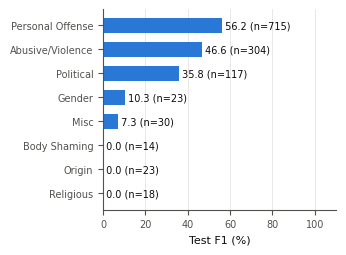

Registered F06 -> figures/fig_06_per_category_f1.png


In [17]:
pred_bin, pred_cat, pred_cat_gated = preds['Tuned on validation']
p, r, f, s = precision_recall_fscore_support(Y_test, pred_cat_gated, zero_division=0)
_, _, f_hate, _ = precision_recall_fscore_support(Y_test[is_hate], pred_cat[is_hate], zero_division=0)
cat_table = pd.DataFrame({
    'Category': TARGET_COLS,
    'Train count': train_df[TARGET_COLS].sum().values,
    'Test support': s,
    'Threshold': cat_thr,
    'Precision': 100 * p,
    'Recall': 100 * r,
    'F1 (all comments)': 100 * f,
    'F1 (hate comments)': 100 * f_hate,
})
display(cat_table)
save_table(cat_table, 'tab_13_per_category_results')
register_asset('T13', 'tables/tab_13_per_category_results.csv (+ .tex)',
               'Per-category test precision, recall, F1 with train count, test support and tuned threshold',
               NOTEBOOK_NAME, 'V. Results (per-category / error analysis)',
               'TABLE X. Per-category results on the BanTH test split (%), with the number of training examples and test support for each category.')

order = cat_table.sort_values('F1 (all comments)')
fig, ax = plt.subplots(figsize=(3.5, 2.6))
ax.barh(order['Category'], order['F1 (all comments)'], color=BLUE, height=0.6)
for y, (f1v, sup) in enumerate(zip(order['F1 (all comments)'], order['Test support'])):
    ax.text(f1v, y, f' {f1v:.1f} (n={sup})', va='center', fontsize=7, color=INK)
ax.set_xlim(0, 110)
ax.set_xlabel('Test F1 (%)')
ax.grid(axis='y', visible=False)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig_06_per_category_f1.png'))
plt.show()
register_asset('F06', 'figures/fig_06_per_category_f1.png',
               'Test F1 per hate category (all comments, tuned thresholds) with test support',
               NOTEBOOK_NAME, 'V. Results',
               'Fig. X. Test F1 for each hate category. Numbers in brackets give the number of test comments in the category.')

## Confusion matrix for hate vs not hate (F05)

Rows are the true label and columns the predicted label (tuned threshold). Each cell shows the count and the percent of its row, so we can see how many hate comments were missed and how many normal comments were wrongly flagged.

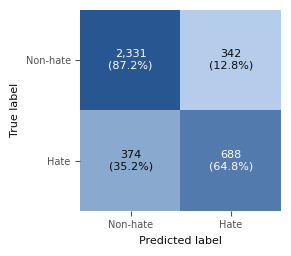

Registered F05 -> figures/fig_05_confusion_matrix.png


In [18]:
cm = confusion_matrix(y_test, pred_bin, labels=[0, 1])
row_pct = 100 * cm / cm.sum(axis=1, keepdims=True)
cmap = LinearSegmentedColormap.from_list('blues', ['#cde2fb', '#104281'])
fig, ax = plt.subplots(figsize=(3.0, 2.6))
ax.imshow(row_pct, cmap=cmap, vmin=0, vmax=100)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]:,}\n({row_pct[i, j]:.1f}%)', ha='center', va='center', fontsize=8,
                color='white' if row_pct[i, j] > 50 else INK)
ax.set_xticks([0, 1], ['Non-hate', 'Hate'])
ax.set_yticks([0, 1], ['Non-hate', 'Hate'])
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig_05_confusion_matrix.png'))
plt.show()
register_asset('F05', 'figures/fig_05_confusion_matrix.png',
               'Binary confusion matrix on the test split (tuned threshold), counts and row percentages',
               NOTEBOOK_NAME, 'V. Results',
               'Fig. X. Confusion matrix of binary hate speech detection on the BanTH test split. Percentages are relative to the true class.')

## Comparison with the BanTH baselines (T14)

We take the baseline table saved by the baseline notebook and add our model, with the tuned thresholds. We add two rows because the paper doesn't say which comments its multi-label scores use. The binary scores are the same in both rows.

Keep in mind that the paper's numbers may come from a slightly different version of the labels (see T09).

In [19]:
baseline_table = pd.read_csv(os.path.join(TAB_DIR, 'tab_08_baseline_comparison.csv'))
tuned_bin = bin_table[bin_table['Threshold'] == 'Tuned on validation'].iloc[0]
tuned_ml = ml_table[ml_table['Threshold'] == 'Tuned on validation']
ours = []
for _, ml in tuned_ml.iterrows():
    scope = 'all comments' if ml['Evaluated on'].startswith('All') else 'hate comments'
    ours.append({'Source': 'This work', 'Model': f'XLM-R dual head (multi-label on {scope})',
                 'Binary Macro-F1': tuned_bin['Macro-F1'], 'Binary Macro-Acc.': tuned_bin['Macro-Acc.'],
                 'Multi-label Macro-F1': ml['Macro-F1'], 'Subset Acc.': ml['Subset Acc.'],
                 'Hamming Loss': ml['Hamming Loss']})
comparison = pd.concat([baseline_table, pd.DataFrame(ours)], ignore_index=True)
display(comparison)
save_table(comparison, 'tab_14_comparison_with_baseline')
register_asset('T14', 'tables/tab_14_comparison_with_baseline.csv (+ .tex)',
               'Published BanTH baselines plus our dual-head XLM-R (tuned thresholds), two multi-label scopes',
               NOTEBOOK_NAME, 'V. Results (main comparison)',
               'TABLE X. Comparison with published baselines on the BanTH test split (%). Baseline values are taken from Haider et al.; lower Hamming loss is better.')

,Source,Model,Binary Macro-F1,Binary Macro-Acc.,Multi-label Macro-F1,Subset Acc.,Hamming Loss
0,BanTH paper,BanglaBERT,76.50000,81.040000,20.820000,54.080000,7.260000
1,BanTH paper,BanglishBERT,75.07000,80.620000,20.610000,52.740000,7.420000
2,BanTH paper,mBERT,74.97000,80.370000,28.240000,52.190000,7.780000
3,BanTH paper,XLM-R,77.35000,81.370000,29.290000,53.280000,7.230000
4,BanTH paper,TB-BERT,76.27000,79.250000,30.170000,54.190000,7.180000
5,BanTH paper,TB-mBERT,77.36000,82.570000,27.070000,54.710000,7.280000
6,BanTH paper,GPT 4o,70.05000,74.300000,36.070000,22.600000,16.910000
7,BanTH paper,GPT 4o + Few-shot,68.77000,74.180000,39.530000,26.760000,14.160000
8,This work,XLM-R dual head (multi-label on all comments),76.23044,75.994407,19.529358,72.369478,4.340696
9,This work,XLM-R dual head (multi-label on hate comments),76.23044,75.994407,28.893843,31.450094,11.028719


Saved: tab_14_comparison_with_baseline (.csv and .tex)
Registered T14 -> tables/tab_14_comparison_with_baseline.csv (+ .tex)


## Training setup table (T10)

All settings in one table for the Methodology section, including the GPU, the chosen max length, the thresholds and the training time.

In [20]:
train_minutes = float(log_df['minutes'].sum())
setup = pd.DataFrame([
    ('Pre-trained encoder', CONFIG['model_name']),
    ('Parameters', f'{n_params / 1e6:.1f}M'),
    ('Heads', 'binary (1 sigmoid) + categories (8 sigmoids) on first-token output'),
    ('Loss', 'BCE (binary) + BCE with pos. weight sqrt(neg/pos) (categories)'),
    ('Optimizer', f"AdamW, lr {CONFIG['learning_rate']}, weight decay {CONFIG['weight_decay']}"),
    ('LR schedule', f"linear warm-up ({int(CONFIG['warmup_ratio'] * 100)}%) then linear decay"),
    ('Batch size', str(CONFIG['batch_size'])),
    ('Max sequence length', f'{MAX_LEN} tokens'),
    ('Epochs', f"max {CONFIG['max_epochs']}, early stopping patience {CONFIG['patience']} (val. loss); best epoch {best_epoch}"),
    ('Dropout', str(CONFIG['dropout'])),
    ('Gradient clipping', str(CONFIG['grad_clip'])),
    ('Precision', 'mixed (fp16)'),
    ('Decision thresholds', f'tuned on validation (binary {bin_thr:.2f})'),
    ('Random seed', str(SEED)),
    ('Hardware', f'Google Colab, {GPU_NAME}'),
    ('Training time', f'{train_minutes:.1f} min'),
], columns=['Setting', 'Value'])
display(setup)
save_table(setup, 'tab_10_training_setup')
register_asset('T10', 'tables/tab_10_training_setup.csv (+ .tex)',
               'Model, hyperparameters, seed, hardware and training time',
               NOTEBOOK_NAME, 'IV. Methodology',
               'TABLE X. Training setup of the dual-head XLM-R model.')

,Setting,Value
0,Pre-trained encoder,xlm-roberta-base
1,Parameters,278.1M
2,Heads,binary (1 sigmoid) + categories (8 sigmoids) o...
3,Loss,BCE (binary) + BCE with pos. weight sqrt(neg/p...
4,Optimizer,"AdamW, lr 2e-05, weight decay 0.01"
5,LR schedule,linear warm-up (10%) then linear decay
6,Batch size,32
7,Max sequence length,128 tokens
8,Epochs,"max 5, early stopping patience 2 (val. loss); ..."
9,Dropout,0.1


Saved: tab_10_training_setup (.csv and .tex)
Registered T10 -> tables/tab_10_training_setup.csv (+ .tex)


## Error examples (T15)

5 hate comments the model missed (false negatives) and 5 normal comments it wrongly flagged (false positives), picked randomly with seed 42. We use them in the error analysis. The LaTeX version is shortened and has no emoji.

In [21]:
def true_categories(i):
    names = [c for j, c in enumerate(TARGET_COLS) if Y_test[i, j] == 1]
    return ', '.join(names) if names else '-'

fn_idx = pd.Series(np.where((y_test == 1) & (pred_bin == 0))[0])
fp_idx = pd.Series(np.where((y_test == 0) & (pred_bin == 1))[0])
picked = [('False negative', i) for i in fn_idx.sample(min(5, len(fn_idx)), random_state=SEED)] + \
         [('False positive', i) for i in fp_idx.sample(min(5, len(fp_idx)), random_state=SEED)]
errors = pd.DataFrame([{
    'Type': kind,
    'ID': test_df.loc[i, 'comment_id'],
    'Text': test_df.loc[i, 'clean_text'],
    'P(hate)': 100 * test_bin_prob[i],
    'True categories': true_categories(i),
} for kind, i in picked])
display(errors)
errors_tex = errors.copy()
errors_tex['Text'] = errors_tex['Text'].map(ascii_short)
save_table(errors, 'tab_15_error_examples', tex_df=errors_tex, float_format='%.1f')
register_asset('T15', 'tables/tab_15_error_examples.csv (+ .tex)',
               '5 false negatives and 5 false positives from the test split (seed 42) with predicted hate probability',
               NOTEBOOK_NAME, 'V. Results (error analysis)',
               'TABLE X. Examples of misclassified test comments. P(hate) is the predicted probability of hate in percent (text shortened; emoji removed).')

,Type,ID,Text,P(hate),True categories
0,False negative,test_03352,Ekdom shoytan lagtese,5.223086,Personal Offense
1,False negative,test_00302,Pasa vaai or take care korce,8.586246,Misc
2,False negative,test_00134,Jahannam janis re beristar,38.237206,Personal Offense
3,False negative,test_03316,Police amader tax khay...behave kub baje,10.502681,Personal Offense
4,False negative,test_00515,Tore jonmo ki mujib sheikh diyeche,40.127716,"Personal Offense, Abusive/Violence"
5,False positive,test_02756,DESH TAR MODDAY KE SORU HOILO.......,68.267952,-
6,False positive,test_01347,Bedi fagol hoy gess,87.070724,-
7,False positive,test_01310,Ami akta kapor kinci oita futa futa cilo,75.255852,-
8,False positive,test_00507,tore India patabo,71.908775,-
9,False positive,test_01427,Ar tor moto may guli wono may guli ra ja ato b...,81.017868,-


Saved: tab_15_error_examples (.csv and .tex)
Registered T15 -> tables/tab_15_error_examples.csv (+ .tex)


## Save predictions, model settings and all metrics (M06, M07, M08)

- test_predictions.csv: every test comment with its probabilities and predictions. The explanation notebook uses it to pick examples.
- model_config.json (next to the checkpoint): everything needed to load the model again, including the thresholds. The explanation and demo notebooks use it.
- metrics_training.json: all scores, settings and thresholds from this run.
- environment_training.txt: library versions and GPU used for training.

In [22]:
pred_df = pd.DataFrame({'comment_id': test_df['comment_id'], 'Label': y_test,
                        'p_hate': test_bin_prob, 'pred_hate': pred_bin})
for j, c in enumerate(TARGET_COLS):
    pred_df[f'true_{c}'] = Y_test[:, j]
    pred_df[f'p_{c}'] = test_cat_prob[:, j]
    pred_df[f'pred_{c}'] = pred_cat_gated[:, j]
pred_df.to_csv(os.path.join(REP_DIR, 'test_predictions.csv'), index=False)

model_config = {
    'model_name': CONFIG['model_name'], 'max_length': MAX_LEN, 'dropout': CONFIG['dropout'],
    'categories': TARGET_COLS, 'weights_file': 'best_model.pt', 'best_epoch': best_epoch,
    'binary_threshold': bin_thr, 'category_thresholds': dict(zip(TARGET_COLS, cat_thr.tolist())),
}
with open(os.path.join(CKPT_DIR, 'model_config.json'), 'w') as f:
    json.dump(model_config, f, indent=2)

metrics = {
    'step': 'training', 'notebook': NOTEBOOK_NAME,
    'date': datetime.now().isoformat(timespec='seconds'), 'seed': SEED,
    'model': CONFIG['model_name'], 'config': CONFIG, 'n_parameters': n_params,
    'token_length': token_stats, 'gpu': GPU_NAME, 'training_minutes': train_minutes,
    'best_epoch': best_epoch, 'thresholds': model_config['binary_threshold'],
    'category_thresholds': model_config['category_thresholds'],
    'checkpoint': os.path.join(CKPT_DIR, 'best_model.pt'),
    'test_binary': bin_table.to_dict(orient='records'),
    'test_multilabel': ml_table.to_dict(orient='records'),
    'test_per_category': cat_table.to_dict(orient='records'),
    'test_confusion_matrix': cm.tolist(),
    'units': 'percent',
}
with open(os.path.join(REP_DIR, 'metrics_training.json'), 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, default=lambda o: o.item() if hasattr(o, 'item') else str(o))

env_lines = [f'Recorded: {datetime.now().isoformat(timespec="seconds")}', f'Notebook: {NOTEBOOK_NAME}',
             f'Seed: {SEED}', f'Python: {sys.version.split()[0]}', f'Platform: {platform.platform()}',
             f'GPU: {GPU_NAME}', '', 'Library versions:']
env_lines += [f'  {pkg}=={version(pkg)}' for pkg in ['torch', 'transformers', 'numpy', 'pandas', 'scikit-learn']]
with open(os.path.join(REP_DIR, 'environment_training.txt'), 'w') as f:
    f.write('\n'.join(env_lines) + '\n')

register_asset('M06', 'evaluation_reports/metrics_training.json',
               'All test scores, thresholds, settings, token lengths, training time and checkpoint path',
               NOTEBOOK_NAME, 'IV. Methodology / V. Results',
               'Not a figure; source for every model result quoted in the text.')
register_asset('M07', 'evaluation_reports/test_predictions.csv',
               'Per-comment test probabilities and predictions (binary and 8 categories)',
               NOTEBOOK_NAME, 'V. Results / explainability input',
               'Not a figure; used to pick explanation examples and for error analysis.')
register_asset('M08', 'evaluation_reports/environment_training.txt',
               'Library versions and GPU used for training',
               NOTEBOOK_NAME, 'IV. Methodology (training setup)',
               'Not a figure; software versions for the training setup.')
print('All saved.')

Registered M06 -> evaluation_reports/metrics_training.json
Registered M07 -> evaluation_reports/test_predictions.csv
Registered M08 -> evaluation_reports/environment_training.txt
All saved.


## Summary

We fine-tuned a dual-head XLM-R model on BanTH, saved the best checkpoint to results/model_checkpoints/best_model.pt, and saved the loss curves (F04), confusion matrix (F05), per-category F1 (F06), the setup table (T10), test results (T11 to T13), the comparison with the BanTH paper (T14) and error examples (T15).

Next, the explanation notebook loads best_model.pt with model_config.json and explains its predictions with LIME and SHAP.

## Remember this

- What we did: fine-tuned XLM-R with two outputs, hate or not and the 8 categories, and saved the model to Drive after every epoch.
- Why: one shared model handles both tasks, and using the same test split and metrics as the BanTH paper lets us compare fairly.
- Key number: binary macro-F1 76.23 on the test set (BanTH paper XLM-R: 77.35), and category macro-F1 28.89 on hate comments (paper XLM-R: 29.29).